In [2]:
import numpy as np
import pandas as pd
from numpy.typing import NDArray
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler

In [3]:
import matplotlib.pyplot as plt

In [5]:
# Импортируем и используем функцию из нашего нового модуля
from visualization_utils import plot_scaling_with_seaborn, plot_correlation_heatmap

In [6]:

# 1. Создаем набор данных
# 100 признаков (n_features), но только 3 из них (n_informative)
# влияют на ответ 'y'. Остальные 97 - мусор.
X: NDArray[np.float64]
y: NDArray[np.float64]
true_coef: NDArray[np.float64]

X, y, true_coef = make_regression(
    n_samples=100,
    n_features=100,
    n_informative=3,
    noise=10,
    coef=True,  # Возвращает "истинные" коэффициенты
    random_state=42
)

In [7]:
# Масштабируем данные - это ВАЖНО для регуляризации
scaler: StandardScaler = StandardScaler()
X_scaled: NDArray[np.float64] = scaler.fit_transform(X)

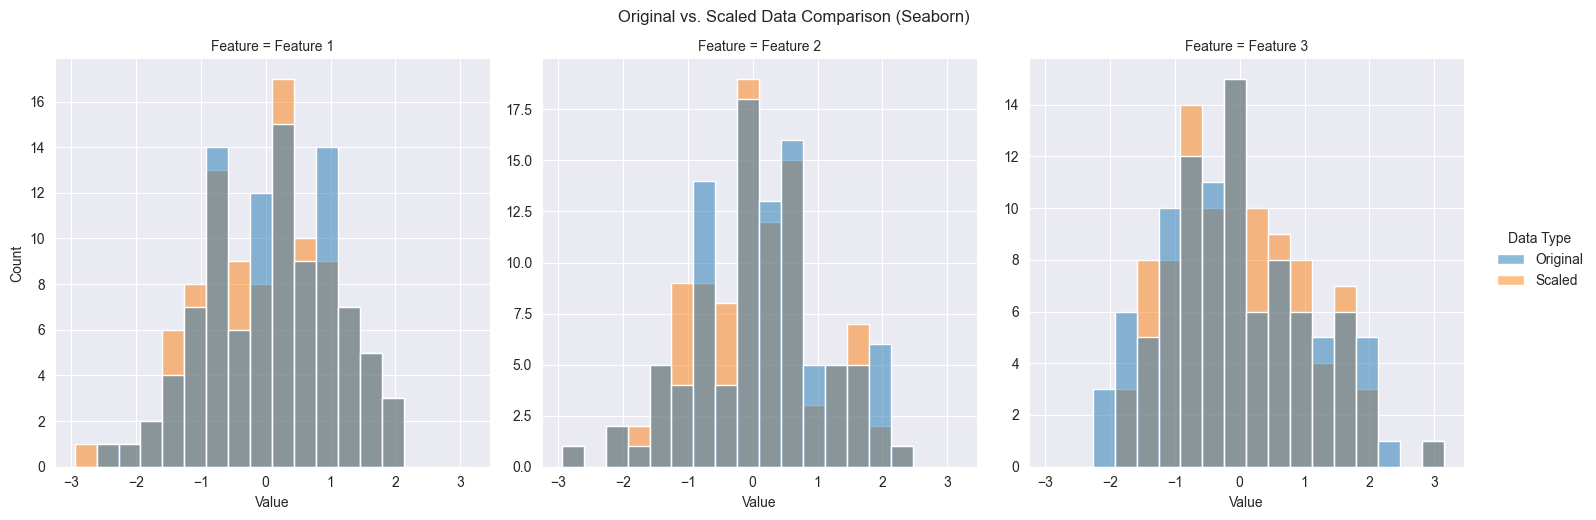

In [8]:
plot_scaling_with_seaborn(X, X_scaled)

In [9]:
# 2. Модели
# alpha - это сила регуляризации. alpha=0 - нет регуляризации.
# Мы используем 'alpha=1.0' (средняя сила)
lr: LinearRegression = LinearRegression() # Без регуляризации
ridge: Ridge = Ridge(alpha=1.0) # L2-регуляризация
lasso: Lasso = Lasso(alpha=1.0) # L1-регуляризация

In [10]:
# 3. Обучаем
lr.fit(X_scaled, y)
ridge.fit(X_scaled, y)
lasso.fit(X_scaled, y)

Lasso()

In [11]:
# 4. Сравниваем коэффициенты (w)
print(f"Истинных ненулевых коэффициентов: {np.sum(true_coef != 0)}")
print("---")
print(f"Ненулевых коэф. у LinearRegression: {np.sum(lr.coef_ != 0)}")
print(f"Ненулевых коэф. у L2 (Ridge):      {np.sum(ridge.coef_ != 0)}")
print(f"Ненулевых коэф. у L1 (Lasso):      {np.sum(lasso.coef_ != 0)}")

# Посмотрим на сами коэффициенты
print("\nКоэффициенты Lasso (L1):")
# np.round(lasso.coef_, 2) округляет до 2 знаков после запятой
print(np.round(lasso.coef_, 2))

Истинных ненулевых коэффициентов: 3
---
Ненулевых коэф. у LinearRegression: 100
Ненулевых коэф. у L2 (Ridge):      100
Ненулевых коэф. у L1 (Lasso):      21

Коэффициенты Lasso (L1):
[ 0.000e+00 -0.000e+00  0.000e+00 -0.000e+00 -1.500e-01 -0.000e+00
 -0.000e+00  0.000e+00  0.000e+00  0.000e+00 -0.000e+00  0.000e+00
 -0.000e+00  0.000e+00 -0.000e+00  0.000e+00  0.000e+00  0.000e+00
 -0.000e+00 -1.900e-01 -0.000e+00  0.000e+00  0.000e+00 -0.000e+00
 -0.000e+00 -8.600e-01  0.000e+00 -0.000e+00  0.000e+00  1.000e-01
  0.000e+00 -0.000e+00 -0.000e+00  2.000e-01 -0.000e+00  0.000e+00
  0.000e+00 -0.000e+00 -1.500e-01  3.296e+01 -0.000e+00  1.300e-01
  0.000e+00 -0.000e+00 -0.000e+00  0.000e+00 -0.000e+00  0.000e+00
 -0.000e+00 -1.500e-01  0.000e+00 -0.000e+00 -0.000e+00  7.110e+00
 -2.000e-02  0.000e+00  1.000e-01  0.000e+00  0.000e+00 -0.000e+00
 -0.000e+00 -0.000e+00  1.070e+00  0.000e+00  0.000e+00 -0.000e+00
  6.400e-01  0.000e+00 -0.000e+00 -0.000e+00 -0.000e+00 -0.000e+00
  0.000e+00  

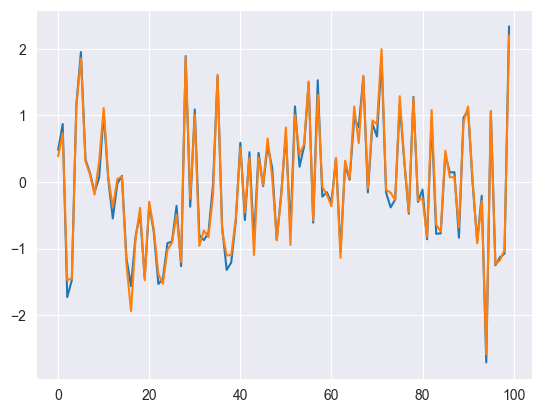

In [14]:
plt.plot(X[0])
plt.plot(X_scaled[0])
plt.show()

In [16]:
X_df = pd.DataFrame(X)
X_scaled_df = pd.DataFrame(X_scaled)

In [19]:
X_df.sample(5)

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
39,-0.300860,0.455904,-1.103670,-0.110665,0.893698,-0.330789,-1.002217,0.608246,-1.880010,-0.707626,...,-0.409687,-0.099094,-0.945746,0.388979,-1.535040,0.361417,-0.459090,1.649481,0.712322,-1.293142
81,0.659451,-0.826112,-0.852387,-0.561842,1.609521,0.475366,-0.608006,1.360116,-0.009845,-2.178211,...,-0.822076,0.685590,3.076860,0.307346,-1.064220,-1.595894,-0.687014,-1.395449,-1.219284,-0.739029
41,-0.113563,0.150602,-0.528916,-1.293122,-0.267137,0.777596,-2.072355,0.674695,2.636669,-0.629221,...,-1.050438,-1.441910,0.947512,-0.377387,0.041896,0.570487,-1.503047,-0.172375,0.846118,0.101723
22,-0.717853,-0.784321,0.525937,-0.198074,-1.775982,0.243891,1.515318,0.701390,1.301102,-2.343039,...,1.433625,2.022174,-0.912588,0.654388,1.194214,-1.258265,0.688496,-1.117327,0.191451,0.636553
8,0.494706,-0.824612,-0.666849,-0.940399,-1.432671,0.197917,0.994447,-0.546042,-1.357518,-0.047371,...,0.514884,1.948343,-1.742222,-0.409308,0.839664,-1.597872,0.276601,-0.974122,0.819925,-0.630025


In [20]:
X_scaled_df.sample(5)

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
27,-0.332844,-0.157034,-0.438259,1.252213,0.464742,-0.374816,-0.077125,-0.305798,-0.501383,1.029642,...,-0.254515,0.131969,0.849114,2.563919,-0.966901,1.606980,-1.158069,-0.159055,-0.739805,-0.324149
91,0.360181,-1.336881,1.584552,1.253311,-1.659404,-0.461184,-0.696971,-0.594723,1.733926,-0.293597,...,-0.550797,0.218535,1.089418,-0.776637,1.586400,-0.574191,-0.122745,1.128486,2.381203,-1.299451
64,-0.919629,-0.012412,-0.747973,-1.971641,-1.422046,1.594515,0.396572,-1.085226,0.661078,-0.036205,...,-0.702860,-1.595482,-1.269129,-0.791642,-1.312251,1.081594,0.165825,0.802712,0.136727,-0.094410
17,-1.102213,0.151036,1.541818,-0.084246,0.100238,-1.952540,-0.392283,-0.685011,-0.975578,0.953050,...,-1.114256,-1.512615,0.485366,-0.133601,1.284716,0.640799,-0.913006,-0.031967,1.315679,-2.494988
16,-0.875472,1.206763,-0.182643,0.409435,-0.224650,-1.589379,0.151284,-1.270950,1.129313,-1.359230,...,-0.204463,-1.642760,-0.196422,0.122148,-1.733537,-0.125108,-0.106001,0.385990,-1.117762,1.208356
